In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
df =pd.read_csv('ushape.csv')
df.columns=[['Feaure1','Featue2','class']]
df.head()

,Feaure1,Featue2,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


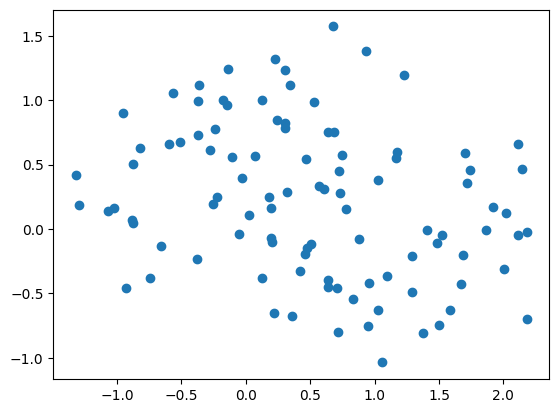

In [8]:
plt.scatter(x=df['Feaure1'],y=df['Featue2'])

In [9]:
X =df.iloc[:,0:2]
y=df.iloc[:,-1]

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [11]:
model = Sequential()
model.add(Dense(10, input_shape=(2,), activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.get_weights()

[array([[ 0.4133758 , -0.37088534,  0.4792543 ,  0.01762736,  0.53663594,
          0.09901607,  0.5962885 , -0.19640732,  0.03413254,  0.6973086 ],
        [ 0.34622365,  0.2951613 ,  0.02345574,  0.4009289 , -0.28837582,
         -0.363378  ,  0.55617434,  0.06883305, -0.48296276,  0.24663895]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.28027833,  0.12711519, -0.49728587,  0.3283429 ,  0.22432709,
          0.0308336 , -0.11329487, -0.3534217 , -0.40132228, -0.12762043],
        [-0.1670489 , -0.2586591 , -0.13255847,  0.08970809, -0.533188  ,
          0.1504057 ,  0.41833228,  0.1657288 ,  0.49625778, -0.3873207 ],
        [ 0.29366422,  0.52321005,  0.28883588,  0.17772478, -0.49092615,
          0.30823994,  0.00673544, -0.09586266, -0.5317379 ,  0.23395163],
        [-0.29622436, -0.2217874 , -0.10054225, -0.37574336,  0.13248348,
         -0.39816713,  0.1360001 ,  0.32750577,  0.05725992, -0.01121616],
        [ 0.22467

In [13]:
initial_weights = model.get_weights()

In [14]:
initial_weights[0]=np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] =np.zeros(model.get_weights()[1].shape)
initial_weights[2] =np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3]=np.zeros(model.get_weights()[3].shape)
initial_weights[4]=np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5]=np.zeros(model.get_weights()[5].shape)
initial_weights[6] =np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7]=np.zeros(model.get_weights()[7].shape)
initial_weights[8]=np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9]=np.zeros(model.get_weights()[9].shape)

In [15]:
model.set_weights(initial_weights)

In [16]:
model.get_weights()

[array([[-1.7277061 , -0.3055961 , -0.10951561, -0.41448623,  1.5414861 ,
         -0.19386373,  0.29455826,  0.13505377,  1.2105523 ,  2.6418743 ],
        [-0.25492448,  0.9693992 ,  0.9766974 ,  0.43999428,  0.78040415,
         -1.0889008 , -0.0408937 , -0.48634407,  0.3382707 ,  0.08371626]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.2645752 , -0.22035557,  0.5943794 , -0.15209536, -0.1951343 ,
         -0.10811263, -0.45672923, -0.19700646,  0.17685957, -0.3749779 ],
        [-0.45652887,  0.1153429 ,  0.1878307 ,  0.32464504,  0.22847345,
         -0.12459148,  0.0952086 ,  0.15177912,  0.12421509,  0.46219498],
        [ 0.1353963 ,  0.3754109 , -0.16993979,  0.28418824,  0.06363663,
         -0.3089058 , -0.07517644,  0.27867287, -0.2943734 ,  0.11579489],
        [ 0.12598874, -0.13175677, -0.15467872,  0.4551636 , -0.19657329,
          0.14820057, -0.14008968,  0.15879041, -0.06213692, -0.16258278],
        [-0.05055

In [17]:
model.compile(loss ='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [18]:
history =model.fit(X,y,epochs=100,validation_split =0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.6368 - loss: 0.6283 - val_accuracy: 0.8500 - val_loss: 0.5521
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6524 - loss: 0.6117 - val_accuracy: 0.8500 - val_loss: 0.5396
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6094 - loss: 0.6198 - val_accuracy: 0.8500 - val_loss: 0.5290
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6197 - loss: 0.6109 - val_accuracy: 0.8500 - val_loss: 0.5176
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7011 - loss: 0.5766 - val_accuracy: 0.8000 - val_loss: 0.5052
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7021 - loss: 0.5733 - val_accuracy: 0.8500 - val_loss: 0.4943
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7562 - loss: 0.5585 - val_accuracy: 0.8500 - val_loss: 0.4839
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7289 - loss: 0.5694 - val_accuracy: 0.8500 - val_loss

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step


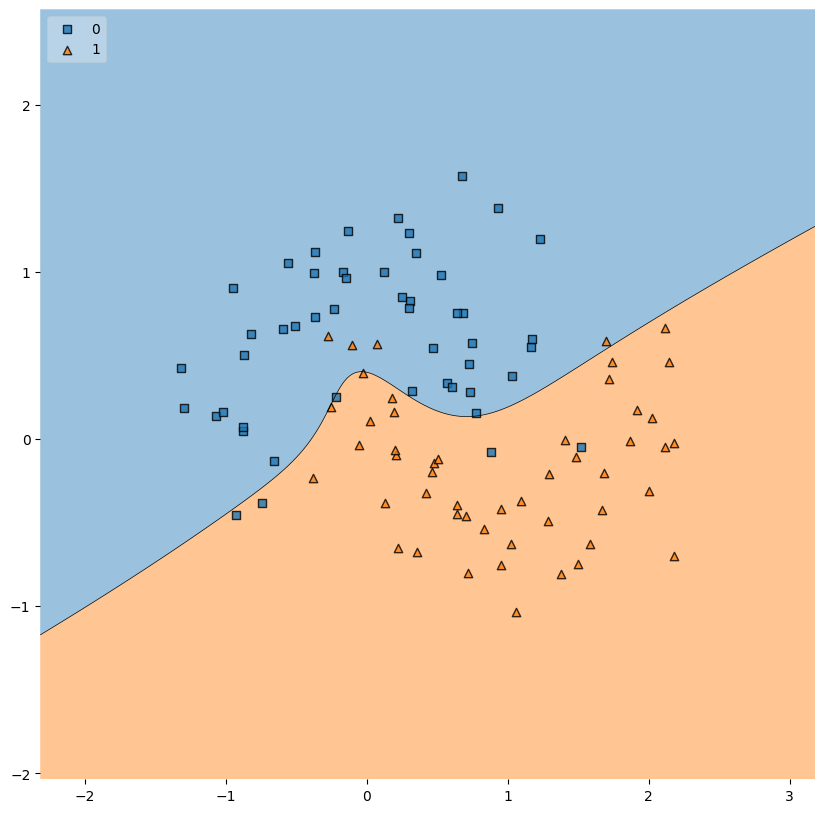

In [23]:
from mlxtend.plotting import plot_decision_regions
plt.figure(figsize=(10,10))
plot_decision_regions(X.values, y.values.astype('int'), model, legend=2)
plt.show()